In [1]:
import os
import pandas as pd
import numpy as np
from statsmodels.stats import weightstats as stests
import matplotlib.pyplot as plt

In [3]:
data= pd.read_csv('Ordenes_productos_C1_M2.csv', sep=';',encoding='latin-1')

In [4]:
#visualizar los primeros registros
data.head(5)

,orden_id,order_item_id,producto_id,vendedor_id,fecha_envio_limite,precio,valor_flete,codigo_postal_vendedor,ciudad_vendedor,departamento_vendedor,nombre_categoria_producto,longitud_nombre_producto,longitud_descripcion_producto,cantidad_fotos_producto,peso_g_producto,longitud_cm_producto,altura_cm_producto,ancho_cm_producto
0,107500PO59A,A,PO59,VE5389,07/04/2018 18:12,271.86,30.72,52435,Mallama,Nariño,Productos ecoamigables,6,7,27,2486,17,11,14
1,37493PS22B,B,PS22,VE1558,20/10/2017 09:07,115.73,4.68,52203,Colon,Nariño,Carnicería,10,31,20,256,43,2,21
2,28050PK20B,B,PK20,VE9159,17/08/2017 08:15,432.99,82.70,66001,Pereira,Risaralda,Deportes,25,5,4,5270,9,27,29
3,52187PA10A,A,PA10,VE3159,23/09/2017 23:27,108.38,35.39,52435,Mallama,Nariño,Electrodomésticos,10,1,6,734,46,48,22
4,84639PR12A,A,PR12,VE5090,07/01/2018 11:50,51.50,11.10,73001,Ibague,Tolima,Frutas y verduras,23,16,35,884,45,26,18


In [10]:
#Media de la muestra
x=data['valor_flete'].mean()

alpha=0.05 

sigma=data['valor_flete'].std()

n=len(data['valor_flete'])

z=1.96

In [11]:
#error estándar
error_estandar = sigma /np.sqrt(n)

limite_inferior = x - z* error_estandar
limite_superior = x + z* error_estandar

intervalo=[float(limite_inferior), float(limite_superior)]
intervalo

[19.66177980971598, 20.444713184166005]

<Axes: xlabel='departamento_vendedor'>

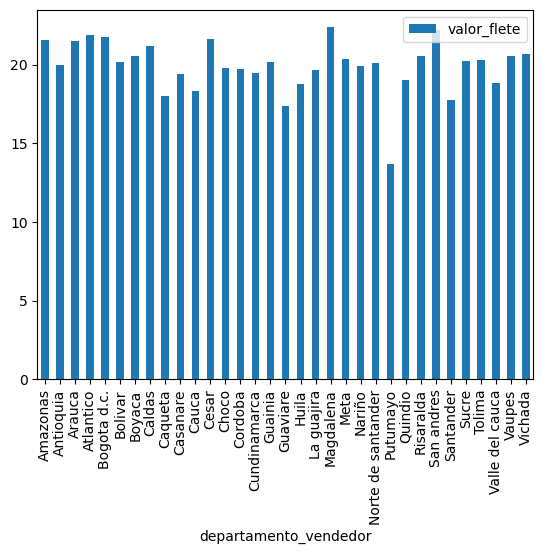

In [13]:
# Elegir las ciudades
data['valor_flete'] = pd.to_numeric(data['valor_flete'], errors='coerce')

data_flete = data.groupby('departamento_vendedor', as_index=False)['valor_flete'].mean()

data_flete.plot.bar(x='departamento_vendedor', y='valor_flete')

In [23]:
#Mostrar promedio de Bolivar y Boyaca
flete_Bolivar=data[data['departamento_vendedor']=='BOLIVAR']['valor_flete']
flete_Boyaca=data[data['departamento_vendedor']=='BOYACA']['valor_flete']

print('Promedio Bolivar: '+str(flete_Bolivar.mean()))
print('Promedio Boyaca: '+str(flete_Boyaca.mean()))

Promedio Bolivar: 20.174795918367348
Promedio Boyaca: 20.556451612903224


In [25]:
# Valores de z y p
ztest ,pval1 = stests.ztest(flete_Bolivar, x2=flete_Boyaca, value=0,alternative='two-sided')

print('Valor de z: '+str(ztest))
print('Valor p: '+ str(pval1))

Valor de z: -0.124380575383133
Valor p: 0.9010139525087727


In [28]:
# Regla de decisión si el p valor es menor que la significancia escogida 
confianza=0.95
significancia=1-confianza

print(str("H0:El promedio de los dos grupos son iguales"))
print(str("H1:El promedio de los dos grupos no son iguales"))

if pval1<significancia:
    print("Rechazar hipótesis nula")
else:
    print("No rechazar hipótesis nula")

H0:El promedio de los dos grupos son iguales
H1:El promedio de los dos grupos no son iguales
No rechazar hipótesis nula
